# 03 — Inhibición recurrente con células de Renshaw

## Objetivo

Construir un circuito neuromotor mínimo con un pool de motoneuronas (MN), un pool pequeño de células de Renshaw (R), excitación **MN → R** e inhibición recurrente **R → MN**.

Las motoneuronas usan el preset *Regular Spiking* y las Renshaw usan *Fast Spiking*. Ambos presets proceden del modelo de Izhikevich y se emplean aquí como aproximaciones funcionales. La elección FS permite representar una interneurona rápida, pero **no constituye una calibración biológica específica de una célula de Renshaw**.


## Base teórica: qué proviene de cada paper

Esta notebook combina dos ideas, pero no reproduce literalmente ninguno de los dos modelos:

1. **Izhikevich (2003)** aporta el modelo neuronal de dos variables y sus patrones funcionales. En esta implementación, las motoneuronas usan el preset **Regular Spiking (RS)** y las Renshaw el preset **Fast Spiking (FS)**.
2. **Williams y Baker (2009)** aporta la arquitectura del lazo: las motoneuronas excitan células de Renshaw y éstas devuelven inhibición a las motoneuronas. Su trabajo estudia cómo la dinámica temporal de este feedback modifica la actividad del pool motor.

### Una precisión importante

Williams y Baker no modelaron sus células de Renshaw como neuronas de Izhikevich FS. Usaron 64 células de Renshaw con un modelo de neurona puntual basado en MacGregor, ajustado mediante propiedades como la poshiperpolarización y la relación corriente–frecuencia. También simularon 377 motoneuronas, retardos de conducción y potenciales postsinápticos con tiempos fisiológicos.

Aquí usamos pools mucho más pequeños y el preset FS de Izhikevich como **proxy funcional de una interneurona capaz de responder rápidamente y con poca adaptación**. Por tanto:

```text
RS para MN + FS para Renshaw = decisión de simplificación del proyecto
lazo MN → Renshaw → MN        = arquitectura inspirada en Williams y Baker
```

No debe afirmarse que Williams y Baker indiquen que una Renshaw “es una neurona Izhikevich Fast Spiking”.

**Referencias fundamentales:**

- Izhikevich, E. M. (2003). *Simple Model of Spiking Neurons*. IEEE Transactions on Neural Networks, 14(6), 1569–1572.
- Williams, E. R., & Baker, S. N. (2009). *Renshaw Cell Recurrent Inhibition Improves Physiological Tremor by Reducing Corticomuscular Coupling at 10 Hz*. Journal of Neuroscience, 29(20), 6616–6624.


## Pregunta central y rol de la semilla

Esta notebook pregunta: **¿puede un grupo de interneuronas activado por las motoneuronas devolver una corriente que limite su actividad posterior?**

La semilla fija, en un mismo orden reproducible:

1. heterogeneidad de las motoneuronas;
2. heterogeneidad de las Renshaw;
3. conexiones `MN → R`;
4. conexiones `R → MN`;
5. ruido de ambos pools.

Así, activar o desactivar la inhibición con la misma semilla compara el mismo circuito y el mismo ruido. La semilla 42 no es “mejor”: es solo una realización reproducible.

### Flujo causal del circuito

In [44]:
from pathlib import Path
import sys

# Funciona si el kernel inicia en la raíz o dentro de notebooks/.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import ipywidgets as widgets
from IPython.display import HTML, display, clear_output

from src.metrics import force_summary, neural_summary, population_activity
from src.muscle import normalize_force, spikes_to_force
from src.renshaw import simulate_renshaw_circuit
from src.visualization import animate_muscle_contraction, plot_raster, plot_renshaw_circuit, spike_times_from_matrix


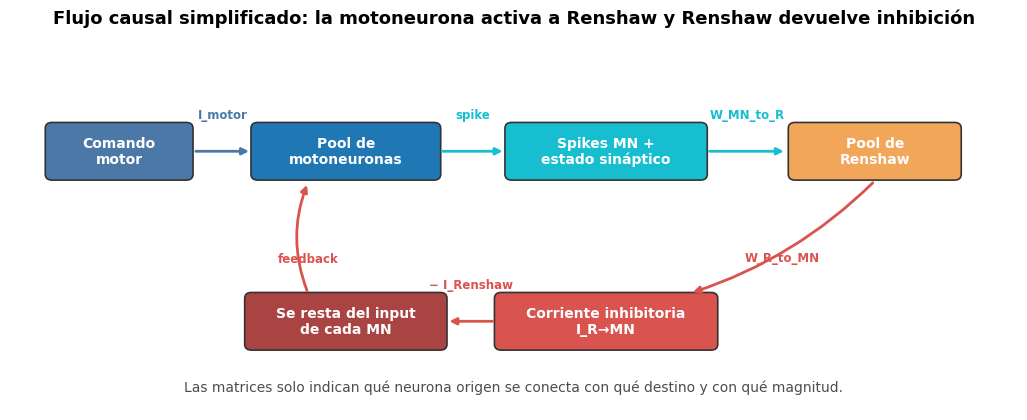

In [45]:
# Recargar el módulo evita que un kernel antiguo conserve una versión previa sin esta función.
import importlib
import src.visualization as visualization

visualization = importlib.reload(visualization)
visualization.plot_renshaw_signal_flow()
plt.show()


## Convención de pesos y corrientes

Las filas de cada matriz son neuronas de **origen** y las columnas son neuronas de **destino**. `W_MN_to_R` y `W_R_to_MN` guardan magnitudes no negativas. La segunda matriz es inhibitoria por cómo se utiliza en la ecuación, no por almacenar números negativos:

$$
I_{MN}=I_{motor}+I_{ruido}-I_{R\rightarrow MN},
\qquad
I_R=I_{MN\rightarrow R}+I_{ruido,R}.
$$

Cada spike incrementa un estado sináptico que luego decae exponencialmente con la constante `synaptic_tau`. La integración neuronal usa Euler y el reset se aplica cuando $v \geq 30$ mV.


## Las dos matrices, paso a paso

Con 20 motoneuronas y 5 células de Renshaw:

- `W_MN_to_R.shape == (20, 5)`: 20 posibles orígenes MN y 5 posibles destinos Renshaw.
- `W_R_to_MN.shape == (5, 20)`: 5 posibles orígenes Renshaw y 20 posibles destinos MN.

Siempre se usa **fila = origen** y **columna = destino**.

### 1. Matriz excitatoria `W_MN_to_R`

`W_MN_to_R[i, j]` indica cuánto excita la motoneurona `i` a la Renshaw `j`.

- Valor `0`: esa conexión no existe.
- Valor positivo: existe una conexión con esa magnitud.

Si `state_MN` contiene el estado sináptico actual de las 20 motoneuronas, la corriente que reciben las 5 Renshaw se calcula como:

$$
\mathbf I_{MN\rightarrow R}=W_{MN\rightarrow R}^{T}\mathbf s_{MN}.
$$

La transpuesta convierte `(20, 5)` en `(5, 20)` para obtener una corriente por cada una de las 5 Renshaw.

### 2. Matriz inhibitoria `W_R_to_MN`

`W_R_to_MN[k, i]` indica la magnitud con que la Renshaw `k` inhibe a la motoneurona `i`.

$$
\mathbf I_{R\rightarrow MN}=W_{R\rightarrow MN}^{T}\mathbf s_R,
$$

y luego esa magnitud se resta:

$$
I_{MN,i}=I_{motor}+I_{ruido,i}-I_{R\rightarrow MN,i}.
$$

Los pesos se almacenan positivos para evitar una doble convención de signos. La palabra “inhibitoria” describe el efecto de la corriente al restarse del input motor.

### Ejemplo mínimo

Si una Renshaw tiene estado sináptico `2` y su peso hacia una MN es `1.5`, la contribución es `2 × 1.5 = 3`. La motoneurona recibe entonces:

```text
input motor + ruido - 3
```

No significa que el voltaje baje automáticamente 3 mV: es una reducción de la corriente de entrada usada por la ecuación de Izhikevich.


In [46]:
def plot_motor_output_comparison(results_without, results_with):
    """Compara la corriente efectiva de entrada y los spikes acumulados del pool MN."""
    time = results_with["time"]

    # Señal interna: corriente total que efectivamente entra a las MN.
    current_without = results_without["I_MN"].mean(axis=0)
    current_with = results_with["I_MN"].mean(axis=0)

    # Output neuronal: suma acumulada de todos los spikes del pool motor.
    cumulative_without = np.cumsum(results_without["spikes_MN"].sum(axis=0))
    cumulative_with = np.cumsum(results_with["spikes_MN"].sum(axis=0))

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

    axes[0].plot(
        time, current_without, color="0.35", linewidth=1.5,
        label="Sin inhibición recurrente",
    )
    axes[0].plot(
        time, current_with, color="tab:red", linewidth=1.5,
        label="Con inhibición Renshaw",
    )
    axes[0].fill_between(
        time, current_with, current_without,
        where=current_without >= current_with,
        color="tab:red", alpha=.12, label="Corriente restada por el feedback",
    )
    axes[0].set(
        title="1. Corriente efectiva media que entra al pool de motoneuronas",
        ylabel="Corriente media (u.a.)",
    )
    axes[0].legend(loc="upper right")
    axes[0].grid(alpha=.25)

    axes[1].plot(
        time, cumulative_without, color="0.35", linewidth=2,
        label=f"Sin inhibición: {int(cumulative_without[-1])} spikes",
    )
    axes[1].plot(
        time, cumulative_with, color="tab:red", linewidth=2,
        label=f"Con inhibición: {int(cumulative_with[-1])} spikes",
    )
    axes[1].fill_between(
        time, cumulative_with, cumulative_without,
        color="tab:blue", alpha=.10,
    )
    axes[1].set(
        title="2. Output neuronal del pool: suma acumulada de spikes",
        xlabel="Tiempo (ms)", ylabel="Spikes acumulados",
    )
    axes[1].legend(loc="upper left")
    axes[1].grid(alpha=.25)

    fig.suptitle(
        "Efecto del feedback Renshaw: primero modifica la corriente de entrada y luego el output de spikes",
        fontsize=13, weight="bold",
    )
    fig.tight_layout(rect=(0, 0, 1, .96))
    plt.show()
    plt.close(fig)
    return current_without, current_with, cumulative_without, cumulative_with

def plot_renshaw_results(results, bin_size_ms=20):
    """Muestra arquitectura, matrices y señales principales del circuito."""
    t = results["time"]
    dt = results["dt"]
    mn_times = spike_times_from_matrix(results["spikes_MN"], t)
    r_times = spike_times_from_matrix(results["spikes_R"], t)
    bins_mn, activity_mn = population_activity(results["spikes_MN"], dt, bin_size_ms)
    bins_r, activity_r = population_activity(results["spikes_R"], dt, bin_size_ms)

    fig, axes = plt.subplots(3, 3, figsize=(17, 13))
    plot_renshaw_circuit(results["W_MN_to_R"], results["W_R_to_MN"], axes[0, 0])

    matrix_specs = [
        (results["W_MN_to_R"], "W_MN_to_R: excitación", "Renshaw destino", "MN origen"),
        (results["W_R_to_MN"], "W_R_to_MN: magnitud inhibitoria", "MN destino", "Renshaw origen"),
    ]
    for ax, (matrix, title, xlabel, ylabel) in zip(axes[0, 1:], matrix_specs):
        im = ax.imshow(matrix, aspect="auto", cmap="viridis", origin="lower", vmin=0)
        ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
        colorbar = fig.colorbar(im, ax=ax, shrink=.75)
        colorbar.set_label("Magnitud del peso")

    plot_raster(mn_times, axes[1, 0]); axes[1, 0].set_title("Raster de motoneuronas")
    plot_raster(r_times, axes[1, 1]); axes[1, 1].set_title("Raster de Renshaw")
    axes[1, 2].plot(t, results["I_R_to_MN"].mean(axis=0), color="tab:red")
    axes[1, 2].set(title="Inhibición media recibida por MN", xlabel="Tiempo (ms)", ylabel="Corriente (u.a.)")
    axes[2, 0].plot(t, results["V_MN"][0]); axes[2, 0].set_title("v de MN representativa (RS)")
    axes[2, 1].plot(t, results["V_R"][0], color="tab:orange"); axes[2, 1].set_title("v de Renshaw representativa (FS proxy)")
    axes[2, 2].step(bins_mn, activity_mn, where="post", label="MN")
    axes[2, 2].step(bins_r, activity_r, where="post", label="Renshaw")
    axes[2, 2].set(title=f"Actividad poblacional ({bin_size_ms} ms)", xlabel="Tiempo (ms)", ylabel="Spikes/bin")
    axes[2, 2].legend()
    for ax in axes.flat:
        ax.grid(alpha=.2)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


## Cómo leer el panel de resultados

1. **Diagrama**: muestra las conexiones entre motoneuronas y Renshaw. No existe una matriz de conexiones `MN → MN` en esta notebook.
2. **Matrices**: `W_MN_to_R` lleva actividad motora hacia Renshaw y `W_R_to_MN` devuelve la magnitud inhibitoria.
3. **Raster MN y R**: muestra cuándo dispara cada neurona.
4. **Corriente inhibitoria media**: es la magnitud interna que Renshaw aporta y que se resta del comando motor.
5. **Actividad poblacional**: cuenta spikes del pool en ventanas temporales.

### Gráfico comparativo final

El gráfico final tiene dos paneles que deben leerse de arriba hacia abajo:

1. **Corriente efectiva media que entra a las MN.** La curva gris corresponde al circuito sin inhibición y la roja al circuito con Renshaw. El área sombreada señala corriente que el feedback resta. Esta corriente sigue siendo una **entrada interna** de las motoneuronas, no su output.
2. **Spikes acumulados del pool.** Cada vez que cualquier motoneurona dispara, la curva aumenta en uno. La altura final es el número total de spikes producidos. Esta suma acumulada es el **output neuronal** que luego alimenta el modelo muscular de la notebook 5.

Las dos simulaciones usan el mismo comando motor, ruido, parámetros y matrices. Sólo cambia si se resta o no `I_R_to_MN`. Si la curva roja de spikes termina más abajo, el feedback redujo el output total. Si las curvas terminan cerca, la inhibición configurada tuvo un efecto pequeño sobre el conteo total, aunque todavía puede haber cambiado el momento de algunos spikes.

La Renshaw implementa feedback negativo, pero no un PID: no existe una referencia deseada, no se calcula un error y no hay términos integral o derivativo.


## GUI

Cada fila define brevemente el parámetro antes de mostrar su control. Los límites pequeños protegen la velocidad y legibilidad de las figuras.

In [47]:
def described_widget(text, widget):
    label = widgets.HTML(f"<div style='width:310px;font-size:13px'>{text}</div>")
    return widgets.HBox([label, widget])

controls_spec = {
    "n_motor": ("<b>Motoneuronas</b><br>Tamaño del pool motor (2–30).", widgets.IntSlider(value=20, min=2, max=30)),
    "n_renshaw": ("<b>Células de Renshaw</b><br>Tamaño del pool inhibitorio (1–10).", widgets.IntSlider(value=5, min=1, max=10)),
    "amplitude": ("<b>Comando motor</b><br>Amplitud del input externo común.", widgets.FloatSlider(value=12, min=0, max=30, step=.5)),
    "input_type": ("<b>Tipo de input</b><br>Forma temporal del comando.", widgets.Dropdown(options=["constant","pulse","ramp","sinusoidal","motor_plan"], value="motor_plan")),
    "parameter_noise": ("<b>Ruido de parámetros</b><br>Heterogeneidad relativa de a, b, c y d.", widgets.FloatSlider(value=.03, min=0, max=.2, step=.01)),
    "input_noise": ("<b>Ruido de input</b><br>Desvío del ruido individual de corriente.", widgets.FloatSlider(value=.5, min=0, max=5, step=.1)),
    "p_mn_to_r": ("<b>Probabilidad MN → R</b><br>Densidad de conexiones excitatorias.", widgets.FloatSlider(value=.5, min=0, max=1, step=.05)),
    "w_mn_to_r": ("<b>Peso MN → R</b><br>Corriente excitatoria por unidad de estado sináptico.", widgets.FloatSlider(value=1.5, min=0, max=5, step=.1)),
    "p_r_to_mn": ("<b>Probabilidad R → MN</b><br>Densidad del feedback inhibitorio.", widgets.FloatSlider(value=.6, min=0, max=1, step=.05)),
    "w_r_to_mn": ("<b>Peso R → MN</b><br>Corriente restada por unidad de estado sináptico.", widgets.FloatSlider(value=1., min=0, max=8, step=.1)),
    "synaptic_tau": ("<b>Constante sináptica</b><br>Decaimiento exponencial en ms.", widgets.FloatSlider(value=10, min=1, max=50, step=1)),
    "total_time": ("<b>Duración</b><br>Tiempo total de simulación (ms).", widgets.IntSlider(value=1000, min=300, max=2000, step=100)),
    "dt": ("<b>dt</b><br>Paso de Euler en ms.", widgets.FloatSlider(value=.5, min=.1, max=1, step=.1)),
    "seed": ("<b>Semilla</b><br>Fija el mismo circuito y ruido en ambas condiciones.", widgets.IntSlider(value=42, min=0, max=999)),
}

output = widgets.Output()
button = widgets.Button(description="Simular y comparar", button_style="success", icon="play")

def run_gui(_=None):
    # Limpiar el widget directamente funciona mejor en VS Code que clear_output global.
    output.clear_output(wait=True)
    button.disabled = True
    button.description = "Simulando..."
    try:
        with output:
            plt.close("all")
            kwargs = {name: item[1].value for name, item in controls_spec.items()}

            # Corrida pareada: lo único que cambia es si I_R→MN se resta del input.
            results_without = simulate_renshaw_circuit(**kwargs, recurrent_inhibition=False)
            results_with = simulate_renshaw_circuit(**kwargs, recurrent_inhibition=True)

            duration_s = kwargs["total_time"] / 1000.0
            n_motor = kwargs["n_motor"]
            spikes_without = int(results_without["spikes_MN"].sum())
            spikes_with = int(results_with["spikes_MN"].sum())
            mean_rate_without = spikes_without / (n_motor * duration_s)
            mean_rate_with = spikes_with / (n_motor * duration_s)

            print("Comparación pareada: mismo input, ruido, parámetros y matrices")
            print(f"Sin inhibición: {spikes_without} spikes | {mean_rate_without:.2f} Hz/MN")
            print(f"Con inhibición: {spikes_with} spikes | {mean_rate_with:.2f} Hz/MN")
            print(f"Cambio de output: {mean_rate_with - mean_rate_without:+.2f} Hz/MN")

            # El panel principal representa el circuito completo con feedback activo.
            plot_renshaw_results(results_with)
            plot_motor_output_comparison(results_without, results_with)
    finally:
        button.disabled = False
        button.description = "Simular y comparar"

button.on_click(run_gui)
display(
    widgets.VBox([
        widgets.HTML("<h3>Controles del circuito MN–Renshaw</h3>"),
        widgets.HTML("<p>Cada clic compara el mismo pool con el feedback Renshaw apagado y encendido.</p>"),
        *[described_widget(text, widget) for text, widget in controls_spec.values()],
        button,
    ]),
    output,
)


Output()

## Supuestos y límites

- Los pesos y unidades de corriente son abstractos; no están ajustados a datos experimentales.
- Las conexiones son Bernoulli aleatorias y no incluyen retardos ni plasticidad.
- RS y FS son proxies funcionales. El circuito permite estudiar comportamiento cualitativo, no reproducir exactamente un circuito espinal.